# 02 — Module A: NLP Sentiment Classification
## Universal Sequence Lab · Assignment 3

**Task:** Binary sentiment classification on IMDb movie reviews (positive / negative).

**Models compared:**
1. Vanilla RNN (baseline — demonstrates vanishing gradient)
2. Bidirectional LSTM
3. Bidirectional GRU
4. Transformer (Encoder + mean pooling)

---

In [6]:
!pip install datasets seaborn scikit-learn -q

import sys
sys.path.append('/content/src')  # adjust if running locally

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

from models import VanillaRNN, LSTMClassifier, GRUClassifier, TransformerClassifier
from dataset import get_imdb_loaders
from train import train_model, plot_learning_curves, plot_confusion_matrix, \
                  print_classification_report, count_parameters, evaluate

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## 1. Load Data


In [7]:
BATCH_SIZE = 64
MAX_LEN    = 256

train_loader, val_loader, test_loader, vocab = get_imdb_loaders(
    batch_size=BATCH_SIZE, max_len=MAX_LEN)

VOCAB_SIZE  = len(vocab)
PAD_IDX     = vocab['<pad>']
N_CLASSES   = 2
print(f'Vocab size: {VOCAB_SIZE:,} | Pad idx: {PAD_IDX}')

Loading IMDb dataset...
Building vocabulary...
  Vocabulary size: 25,004
  Train: 22500 | Val: 2500 | Test: 25000
Vocab size: 25,004 | Pad idx: 0


## 2. Define Hyperparameters & Initialize Models


In [8]:
# Shared hyperparameters
EMBED_DIM  = 128
HIDDEN_DIM = 256
N_LAYERS   = 2
DROPOUT    = 0.3
N_EPOCHS   = 10
LR         = 1e-3

# Transformer-specific
N_HEADS  = 4
FF_DIM   = 512
T_LAYERS = 3

models_config = {
    'VanillaRNN':  VanillaRNN(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, N_CLASSES,
                               N_LAYERS, DROPOUT, PAD_IDX),
    'BiLSTM':      LSTMClassifier(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, N_CLASSES,
                                   N_LAYERS, True, DROPOUT, PAD_IDX),
    'BiGRU':       GRUClassifier(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, N_CLASSES,
                                  N_LAYERS, True, DROPOUT, PAD_IDX),
    'Transformer': TransformerClassifier(VOCAB_SIZE, EMBED_DIM, N_HEADS, FF_DIM,
                                          N_CLASSES, T_LAYERS, DROPOUT, PAD_IDX),
}

print('Model parameter counts:')
for name, model in models_config.items():
    print(f'\n  {name}:')
    count_parameters(model)

Model parameter counts:

  VanillaRNN:
  Total params:     3,431,426
  Trainable params: 3,431,426

  BiLSTM:
  Total params:     5,569,026
  Trainable params: 5,569,026

  BiGRU:
  Total params:     4,977,154
  Trainable params: 4,977,154

  Transformer:
  Total params:     3,795,586
  Trainable params: 3,795,586


In [9]:
import os
os.makedirs('/content/models', exist_ok=True)

## 3. Train All Models


In [10]:
histories = {}
criterion = nn.CrossEntropyLoss()

for name, model in models_config.items():
    print(f'\n{'='*50}')
    print(f' Training: {name}')
    print(f'{'='*50}')
    model = model.to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

    hist = train_model(
        model, train_loader, val_loader, optimizer, criterion, DEVICE,
        n_epochs=N_EPOCHS, task='classification', use_lengths=True,
        scheduler=scheduler, model_name=name,
        save_path=f'/content/models/nlp_{name}.pt'
    )
    histories[name] = hist
    models_config[name] = model  # keep model in GPU


 Training: VanillaRNN
[VanillaRNN] Epoch 01/10 | Train Loss: 0.6995 | Val Loss: 0.6963 | Val Acc: 0.5096 | 16.8s
[VanillaRNN] Epoch 02/10 | Train Loss: 0.7028 | Val Loss: 0.7056 | Val Acc: 0.5076 | 12.8s
[VanillaRNN] Epoch 03/10 | Train Loss: 0.7050 | Val Loss: 0.7087 | Val Acc: 0.4932 | 12.5s
[VanillaRNN] Epoch 04/10 | Train Loss: 0.7027 | Val Loss: 0.6937 | Val Acc: 0.5152 | 12.5s
[VanillaRNN] Epoch 05/10 | Train Loss: 0.7031 | Val Loss: 0.6928 | Val Acc: 0.5152 | 12.9s
[VanillaRNN] Epoch 06/10 | Train Loss: 0.7040 | Val Loss: 0.6929 | Val Acc: 0.5148 | 12.4s
[VanillaRNN] Epoch 07/10 | Train Loss: 0.7037 | Val Loss: 0.6962 | Val Acc: 0.5148 | 12.5s
[VanillaRNN] Epoch 08/10 | Train Loss: 0.7002 | Val Loss: 0.6993 | Val Acc: 0.4928 | 12.5s
[VanillaRNN] Epoch 09/10 | Train Loss: 0.6998 | Val Loss: 0.6967 | Val Acc: 0.4928 | 12.6s
[VanillaRNN] Epoch 10/10 | Train Loss: 0.6986 | Val Loss: 0.6942 | Val Acc: 0.4932 | 12.5s

 Training: BiLSTM
[BiLSTM] Epoch 01/10 | Train Loss: 0.6271 | Val 

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


[Transformer] Epoch 01/10 | Train Loss: 0.5958 | Val Loss: 0.4677 | Val Acc: 0.7800 | 26.7s
[Transformer] Epoch 02/10 | Train Loss: 0.4224 | Val Loss: 0.4510 | Val Acc: 0.8004 | 26.6s
[Transformer] Epoch 03/10 | Train Loss: 0.3667 | Val Loss: 0.3943 | Val Acc: 0.8432 | 26.6s
[Transformer] Epoch 04/10 | Train Loss: 0.3475 | Val Loss: 0.3958 | Val Acc: 0.8456 | 26.9s
[Transformer] Epoch 05/10 | Train Loss: 0.3317 | Val Loss: 0.3968 | Val Acc: 0.8408 | 26.7s
[Transformer] Epoch 06/10 | Train Loss: 0.3263 | Val Loss: 0.3822 | Val Acc: 0.8476 | 26.2s
[Transformer] Epoch 07/10 | Train Loss: 0.3228 | Val Loss: 0.3924 | Val Acc: 0.8472 | 26.3s
[Transformer] Epoch 08/10 | Train Loss: 0.3196 | Val Loss: 0.4475 | Val Acc: 0.8352 | 26.3s
[Transformer] Epoch 09/10 | Train Loss: 0.3179 | Val Loss: 0.4019 | Val Acc: 0.8500 | 26.4s
[Transformer] Epoch 10/10 | Train Loss: 0.3203 | Val Loss: 0.4058 | Val Acc: 0.8476 | 26.4s


## 4. Learning Curves


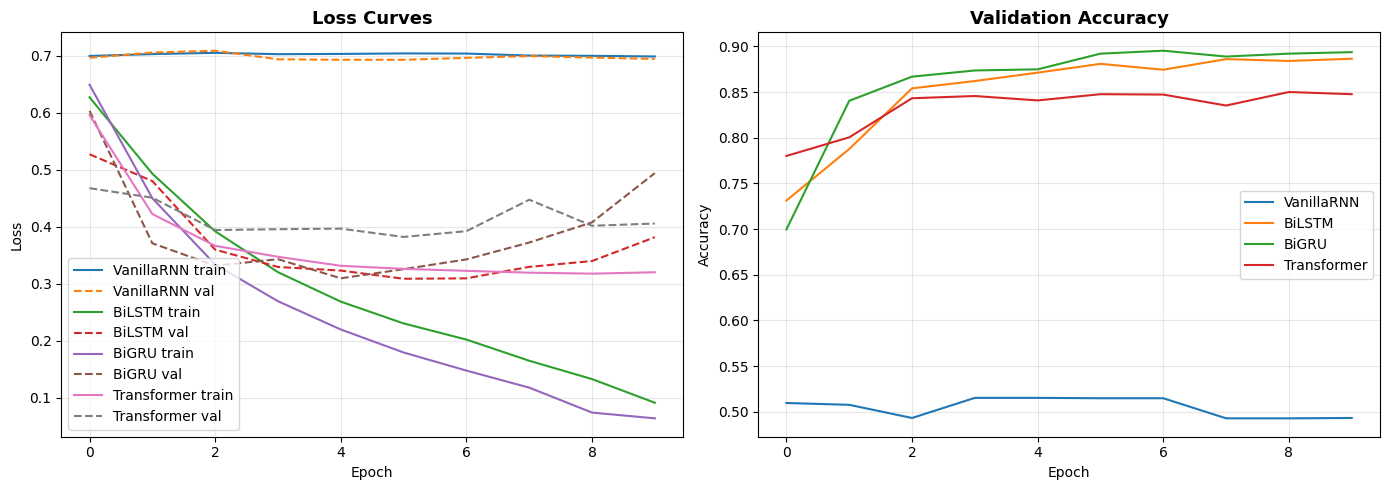

In [11]:
fig = plot_learning_curves(histories, task='classification')

## 5. Test Set Evaluation & Confusion Matrices


In [12]:
results = {}

for name, model in models_config.items():
    # Load best checkpoint
    model.load_state_dict(torch.load(f'/content/models/nlp_{name}.pt',
                                      map_location=DEVICE))
    test_loss, preds, labels = evaluate(model, test_loader, criterion, DEVICE,
                                         task='classification', use_lengths=True)
    acc = (preds == labels).mean()
    results[name] = {'test_loss': test_loss, 'test_acc': acc,
                     'preds': preds, 'labels': labels}
    print(f'{name:15s} | Test Loss: {test_loss:.4f} | Test Acc: {acc:.4f}')

VanillaRNN      | Test Loss: 0.6933 | Test Acc: 0.5070
BiLSTM          | Test Loss: 0.3407 | Test Acc: 0.8699
BiGRU           | Test Loss: 0.3457 | Test Acc: 0.8617
Transformer     | Test Loss: 0.4012 | Test Acc: 0.8417


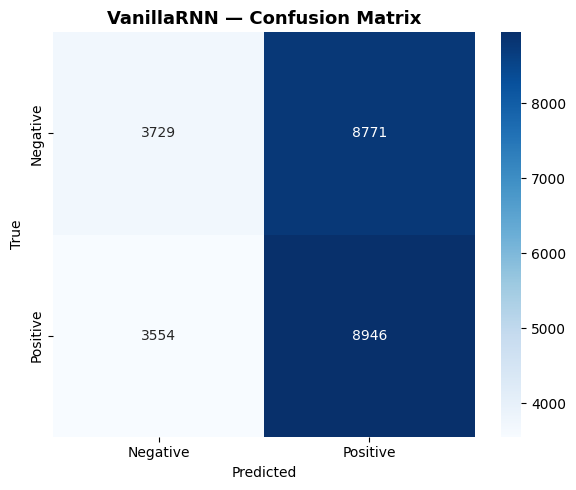

              precision    recall  f1-score   support

    Negative       0.51      0.30      0.38     12500
    Positive       0.50      0.72      0.59     12500

    accuracy                           0.51     25000
   macro avg       0.51      0.51      0.48     25000
weighted avg       0.51      0.51      0.48     25000




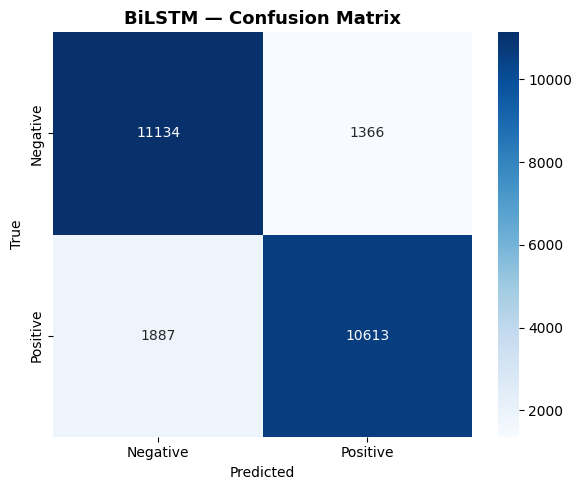

              precision    recall  f1-score   support

    Negative       0.86      0.89      0.87     12500
    Positive       0.89      0.85      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000




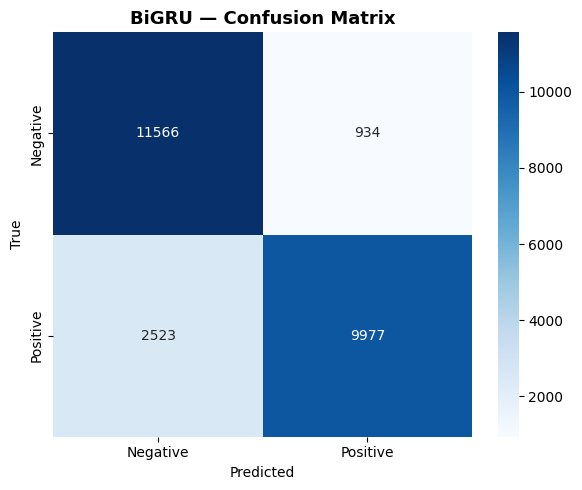

              precision    recall  f1-score   support

    Negative       0.82      0.93      0.87     12500
    Positive       0.91      0.80      0.85     12500

    accuracy                           0.86     25000
   macro avg       0.87      0.86      0.86     25000
weighted avg       0.87      0.86      0.86     25000




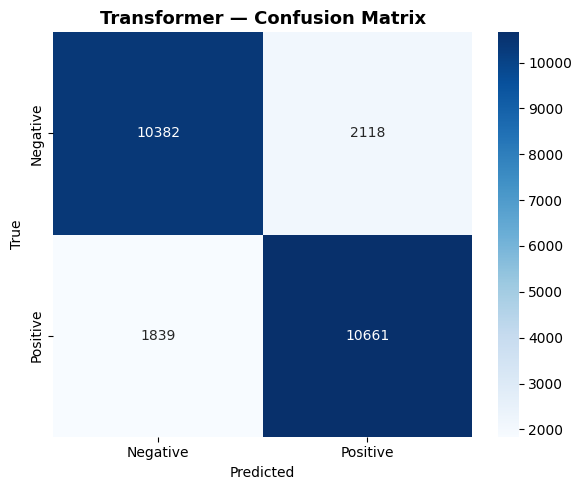

              precision    recall  f1-score   support

    Negative       0.85      0.83      0.84     12500
    Positive       0.83      0.85      0.84     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000




In [13]:
for name, res in results.items():
    plot_confusion_matrix(res['labels'], res['preds'],
                          ['Negative', 'Positive'], title=f'{name} — Confusion Matrix')
    print_classification_report(res['labels'], res['preds'], ['Negative', 'Positive'])
    print()

## 6. Vanishing Gradient Analysis — RNN vs LSTM


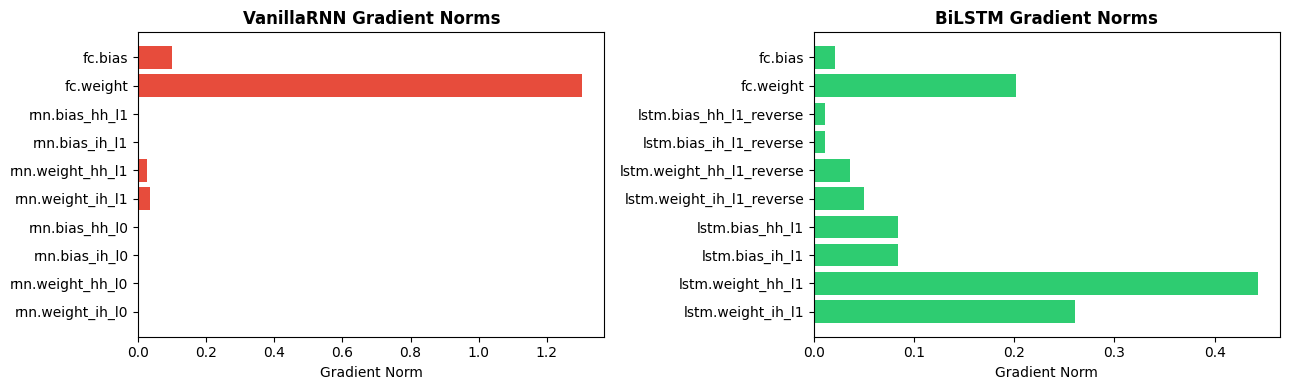

Note: RNN gradients in early layers are near-zero (vanishing gradient problem)


In [14]:
# Compare gradient norms at first vs last layer to illustrate vanishing gradient
def get_gradient_norms(model, loader, criterion, device, use_lengths=True):
    model.train()
    batch = next(iter(loader))
    src, lengths, labels = batch
    src, labels = src.to(device), labels.to(device)
    pred = model(src, lengths) if use_lengths else model(src)
    loss = criterion(pred, labels)
    loss.backward()
    norms = {}
    for name, param in model.named_parameters():
        if param.grad is not None:
            norms[name] = param.grad.norm().item()
    model.zero_grad()
    return norms

rnn_norms  = get_gradient_norms(models_config['VanillaRNN'], train_loader, criterion, DEVICE)
lstm_norms = get_gradient_norms(models_config['BiLSTM'],     train_loader, criterion, DEVICE)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, norms, title, color in zip(
    axes, [rnn_norms, lstm_norms], ['VanillaRNN Gradient Norms', 'BiLSTM Gradient Norms'],
    ['#e74c3c', '#2ecc71']):
    layers = list(norms.keys())
    values = list(norms.values())
    ax.barh(layers[-10:], values[-10:], color=color)  # last 10 params
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Gradient Norm')

plt.tight_layout()
plt.savefig('gradient_analysis.png', bbox_inches='tight')
plt.show()
print('Note: RNN gradients in early layers are near-zero (vanishing gradient problem)')